In [79]:
import pandas as pd 

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [80]:
#tamaño del dataset
dataset.shape

(398, 8)

In [81]:
#busqueda de valores nulos
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [82]:
#reduccion de valores nulos
dataset = dataset.dropna()
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [83]:
#Columna origen
#Nota: 1)USA
#      2)Europe
#      3)Japan

dataset.Origin.value_counts()

Origin
1    245
3     79
2     68
Name: count, dtype: int64

In [84]:
#Convierte la columna a categorica
dataset["Origin"] = dataset["Origin"].map({1:"USA", 2:"Europe", 3:"Japan"})
dataset.head(20)

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA
5,15.0,8,429.0,198.0,4341.0,10.0,70,USA
6,14.0,8,454.0,220.0,4354.0,9.0,70,USA
7,14.0,8,440.0,215.0,4312.0,8.5,70,USA
8,14.0,8,455.0,225.0,4425.0,10.0,70,USA
9,15.0,8,390.0,190.0,3850.0,8.5,70,USA


In [85]:
#gener variables dummy para indicar la procedencia
dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True


In [86]:
#Note que aca no se usa train_test_split, ya que se usara la validacion cruzada para evaluar el modelo.

train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)    

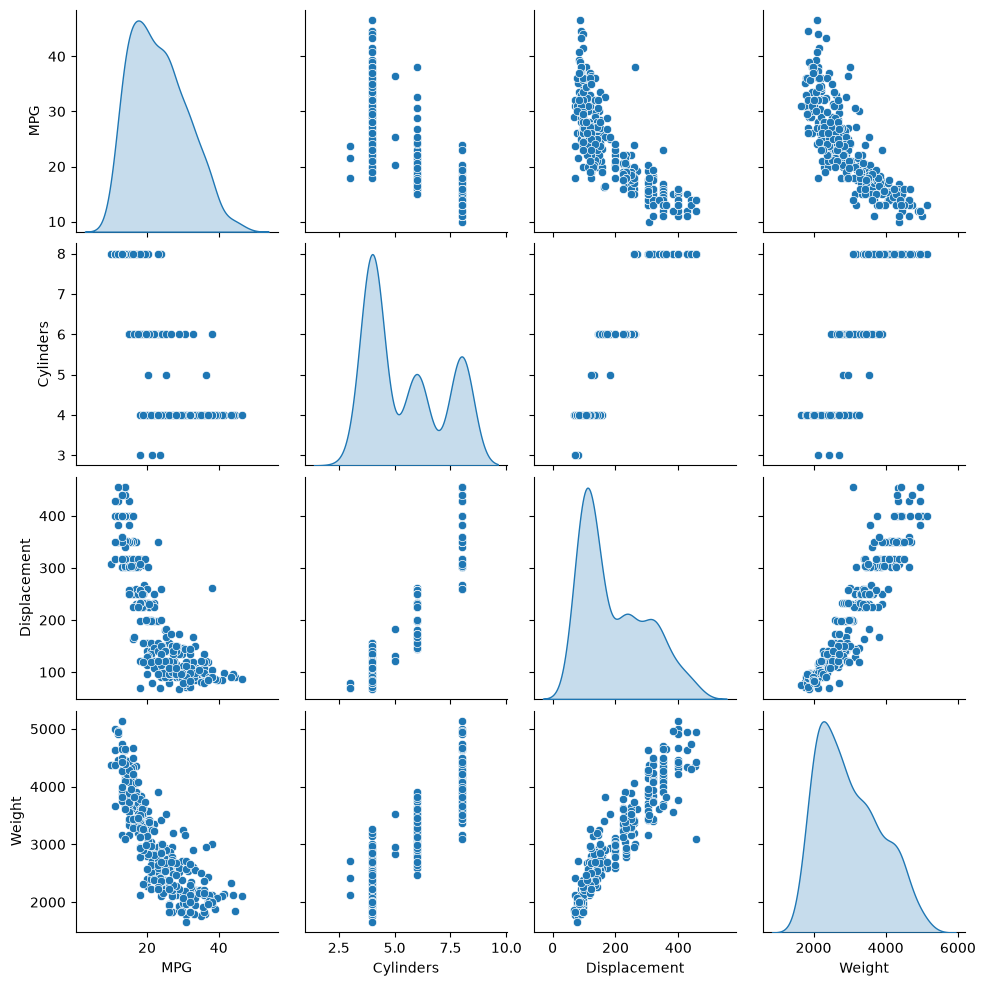

In [87]:
#las millas por galon (mpg) son funciones de las demas variables 
import seaborn as sns
sns.pairplot(train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde")

In [88]:
#Calculo de algunas estadisticas generales

train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


In [89]:
#particionamiento de los datos en features y labels 

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")

In [90]:
#estandarizacion de los datos

train_dataset.describe().transpose()[["mean", "std"]]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642


In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(data=scaler.fit_transform(train_dataset), columns=train_dataset.columns,).describe().transpose()[["mean", "std"]]

,mean,std
MPG,-2.206303e-16,1.001596
Cylinders,2.022444e-16,1.001596
Displacement,7.990777e-17,1.001596
Horsepower,-1.980016e-17,1.001596
Weight,-9.051500e-17,1.001596
Acceleration,-5.275327e-16,1.001596
Model Year,9.419217e-16,1.001596
Europe,3.394312e-17,1.001596
Japan,2.828594e-18,1.001596
USA,1.697156e-17,1.001596


In [92]:
#regresion lineal con una sola variable
horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]
test_horsepower = test_features[["Horsepower"]]

horsepower_scaler.fit(train_horsepower)

standardized_train_horsepower = horsepower_scaler.transform(train_horsepower)
standardized_test_horsepower = horsepower_scaler.transform(test_horsepower)


In [93]:
#modelo de regresion lineal 

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression()
horsepower_model.fit(standardized_train_horsepower, train_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-5.9]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,23.31
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[17.72]


In [94]:
#intercepto

horsepower_model.intercept_

np.float64(23.31050955414013)

In [95]:
#coeficientes
horsepower_model.coef_

array([-5.89948889])

In [96]:
import numpy as np

x = pd.DataFrame({"Horsepower": np.linspace(0, 250, 251)})
x.head()

,Horsepower
0,0.0
1,1.0
2,2.0
3,3.0
4,4.0


In [97]:
#predicciones del modelo

scaled_x = horsepower_scaler.transform(x)
y = horsepower_model.predict(scaled_x)
y[:5]

array([39.57626034, 39.42115555, 39.26605075, 39.11094596, 38.95584117])

In [98]:
import matplotlib.pyplot as plt

def plot_horsepower_model(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()
    

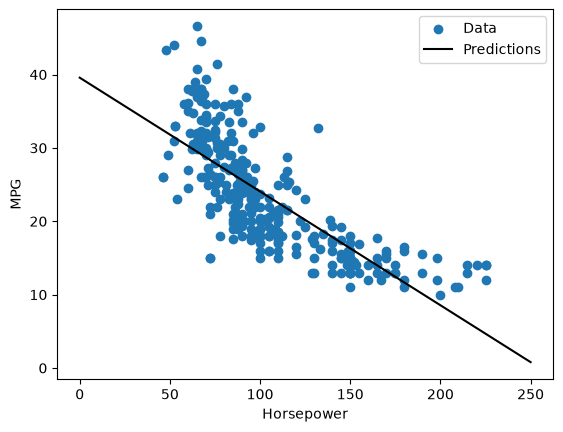

In [99]:
plot_horsepower_model(x, y)

In [100]:
#evaluacion

from sklearn.metrics import mean_squared_error

test_results = {}
y_pred = horsepower_model.predict(standardized_test_horsepower)

test_results["horsepower_model"] = mean_squared_error(y_true=test_labels, y_pred=y_pred)

test_results

{'horsepower_model': 20.829300555790315}

In [101]:
# Regresión lineal con todas las variables

features_scaler = StandardScaler()

features_scaler.fit(train_features)

standarized_train_features = features_scaler.transform(train_features)
standarized_test_features = features_scaler.transform(test_features)

linear_model = LinearRegression()
linear_model.fit(standarized_train_features, train_labels)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.79, 2.4 ,-1.35,..., 0.43, 0.57,-0.81]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,23.31
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[39.72,20.51,19.18,..., 4.35, 3.21, 0. ]"


In [102]:
# Intercepto
linear_model.intercept_

np.float64(23.310509554140125)

In [103]:
# Coeficientes
linear_model.coef_

array([-0.78715361,  2.40329414, -1.35280162, -5.10984346, -0.26461302,
        2.92072687,  0.42671757,  0.57369578, -0.80879752])

In [104]:
def plot_predictions(y_true, y_pred):

    ax = plt.axes(aspect="equal")
    plt.scatter(y_true, y_pred)
    plt.xlabel("True Values [MPG]")
    plt.ylabel("Predictions [MPG]")
    lims = [0, 50]
    plt.xlim(lims)
    plt.ylim(lims)
    _ = plt.plot(lims, lims)

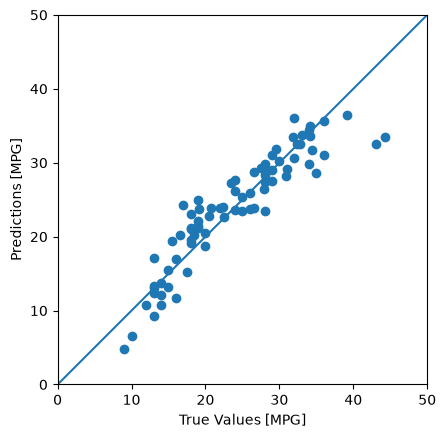

In [105]:
test_predictions = linear_model.predict(standarized_test_features)

plot_predictions(
      y_true=test_labels,
      y_pred=test_predictions,
  )    

In [106]:
test_results["linear_model"] = mean_squared_error(
      y_true=test_labels,
      y_pred=test_predictions,
  )

test_results

{'horsepower_model': 20.829300555790315, 'linear_model': 10.1720922836876}

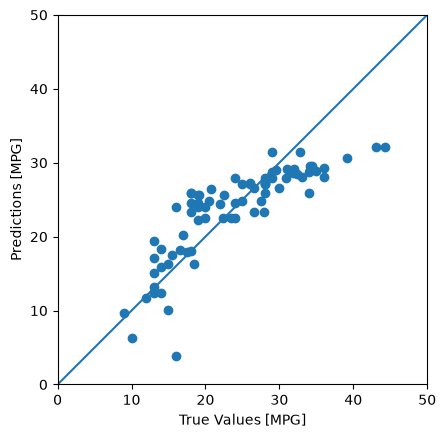

In [108]:
plot_predictions(
    y_true = test_labels,
    y_pred = horsepower_model.predict(standardized_test_horsepower),
)

In [110]:
# Red neuronal con todas las variables

from sklearn.neural_network import MLPRegressor
mlp = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)

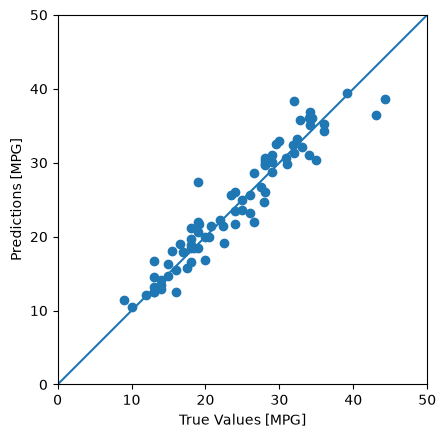

In [111]:
mlp.fit(standarized_train_features, train_labels)

test_predictions = mlp.predict(standarized_test_features)

plot_predictions(
    y_true=test_labels,
    y_pred=test_predictions,
)

In [112]:
test_results["mlp"] = mean_squared_error(
    y_true=test_labels,
    y_pred=test_predictions,
)

In [113]:
# almacenamiento de los modelos y del scaler de features

import os
import pickle


with open("../submission/mlp.pkl", "wb") as file:
    pickle.dump(mlp, file)

with open("../submission/features_scaler.pkl", "wb") as file:
    pickle.dump(features_scaler, file)

In [114]:
# Uso del modelo

import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset = dataset.dropna()
dataset["Origin"] = dataset["Origin"].map(
    {1: "USA", 2: "Europe", 3: "Japan"},
)
dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
y_true = dataset.pop("MPG")

with open("../submission/mlp.pkl", "rb") as file:
    new_mlp = pickle.load(file)

with open("../submission/features_scaler.pkl", "rb") as file:
    new_features_scaler = pickle.load(file)

standarized_dataset = new_features_scaler.transform(dataset)
y_pred = new_mlp.predict(standarized_dataset)

mean_squared_error(
    y_true=y_true,
    y_pred=y_pred,
)

7.744565284379878